Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
INTERGENIC_TES_DISTANCES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\TE_Intergenic_With_Distances_Cingluate_cortex.bed"
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\Expression_TE_DESeq_Cingluate_cortex.csv"
THRESHOLD_DISTANCE = 4000
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\SraRunTable_Aldinger20.csv"

Histogram

     0        1        2               3      4  5     6     7     8   \
0  chr1  1017169  1018876  TE_LTR12C_dup1  11165  -  ERV1   LTR  chr1   
1  chr1  1408001  1408288  TE_AluJb_dup76   1799  +   Alu  SINE  chr1   
2  chr1  1408480  1408622   TE_L1MC4_dup4    281  -    L1  LINE  chr1   
3  chr1  1408762  1409016  TE_AluSz_dup42   1841  -   Alu  SINE  chr1   
4  chr1  1412251  1412721   TE_LTR2B_dup1   3762  -  ERV1   LTR  chr1   

        9        10               11 12 13    14  
0  1011996  1013193  ENSG00000224969  .  -  3977  
1  1409095  1410618        MRPL20-DT  .  +   808  
2  1401908  1407293           MRPL20  .  -  1188  
3  1401908  1407293           MRPL20  .  -  1470  
4  1401908  1407293           MRPL20  .  -  4959  
     Start     End  Count
0      1.0   500.9    685
1    500.9  1000.8    573
2   1000.8  1500.7    485
3   1500.7  2000.6    415
4   2000.6  2500.5    356
5   2500.5  3000.4    307
6   3000.4  3500.3    289
7   3500.3  4000.2    261
8   4000.2  4500.1   

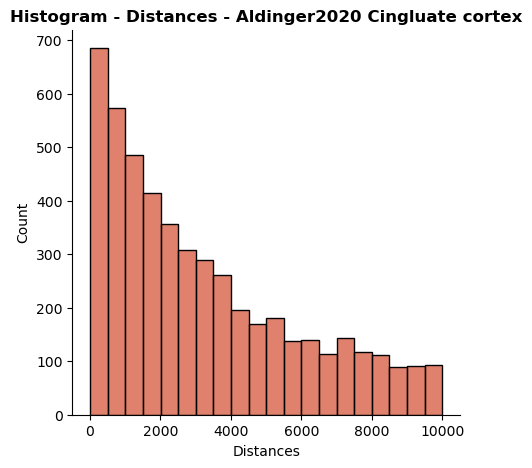

In [3]:
TEs_df = pd.read_csv(INTERGENIC_TES_DISTANCES, sep = '\t', header = None)
print(TEs_df.head())

TEs_df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']

def plot_histogram(df):
    fig, ax = plt.subplots(figsize = (5,5))

    final_df = df[df['Distances'] < 10000]

    sns.histplot(data = final_df, x = 'Distances', bins = 20, color = '#D5573B')

    ax.set_title('Histogram - Distances - Aldinger2020 Cingluate cortex', fontweight = 'bold', fontsize = 12)
    sns.despine()
    plt.plot()
    get_count(ax)

def get_count(ax): # Alternativamente podia utilizar o numpy.histogram
    patches = ax.patches # Uma patch é um objeto gráfico 2D que representa uma forma geométrica (ou seja é tipo os pontos e as barras)
    bin_count = []
    bin_edges = []

    for patch in patches: # Só há 20 barras, há uma que não vai ficar nas edges
        bin_count.append(patch.get_height()) # Também podia ter feito bin_count = [patch for patch in patches], mas assim é mais eficiente
        bin_edges.append(patch.get_x())

    bin_width = patch.get_width()
    bin_edges.append(patches[-1].get_x() + bin_width) # Para conseguir a última edge

    hist_df = pd.DataFrame( {
                'Start' : bin_edges[:-1],
                'End' : bin_edges[1:],
                'Count' : bin_count
    }
    )
    print(hist_df)

plot_histogram(TEs_df)


PCA Intergenics - Data

In [4]:
# Read files
expr_df = pd.read_csv(EXPRESSION_FILE)
clinical_df = pd.read_csv(CLINICAL_DATA)

# Merge to get intergenic
print(TEs_df.head())
proximal = TEs_df[TEs_df['Distances'] < 4000]
print(TEs_df)
TEs_df = TEs_df.drop(index = proximal.index)
TEs_df = TEs_df[['TE_Name']]
expr_df = expr_df.rename(columns = {'Unnamed: 0' : 'TE_Name'})
expr_df = expr_df.merge(TEs_df, on = 'TE_Name', how = 'inner')

# Organize clinical data
clinical_df = clinical_df[['Sample_Name', 'Run', 'Condition']]

# Separate names and counts
TEs_names = expr_df.iloc[:, 0]
counts = expr_df.iloc[:, 1:]

# Make log2cpm
library_size = counts.sum(axis = 0)
cpm = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm + 1)

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

# PCA
pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# Merge it all
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_df, on = 'Sample_Name', how = 'inner')

pca_df.head()

  TE_Chr  TE_Start   TE_End         TE_Name  TE_Score TE_Strand TE_Class-id  \
0   chr1   1017169  1018876  TE_LTR12C_dup1     11165         -        ERV1   
1   chr1   1408001  1408288  TE_AluJb_dup76      1799         +         Alu   
2   chr1   1408480  1408622   TE_L1MC4_dup4       281         -          L1   
3   chr1   1408762  1409016  TE_AluSz_dup42      1841         -         Alu   
4   chr1   1412251  1412721   TE_LTR2B_dup1      3762         -        ERV1   

  TE_Family_id Gene_Chr  Gene_Start  Gene_End        Gene_Name Gene_Score  \
0          LTR     chr1     1011996   1013193  ENSG00000224969          .   
1         SINE     chr1     1409095   1410618        MRPL20-DT          .   
2         LINE     chr1     1401908   1407293           MRPL20          .   
3         SINE     chr1     1401908   1407293           MRPL20          .   
4          LTR     chr1     1401908   1407293           MRPL20          .   

  Gene_Strand  Distances  
0           -       3977  
1       

,Sample_Name,PC1,PC2,Run,Condition
0,1038_CTL_CCTX,40.305679,-14.685515,SRR8734756,Ctrl
1,1614_CTL_CCTX,-21.803368,45.598186,SRR8734757,Ctrl
2,4724_CTL_CCTX,-14.160851,29.744063,SRR8734758,Ctrl
3,4725_CTL_CCTX,42.624700,-20.184019,SRR8734759,Ctrl
4,6355_RTT_CCTX,-74.361407,-48.676475,SRR8734760,RTT


PCA - Graph

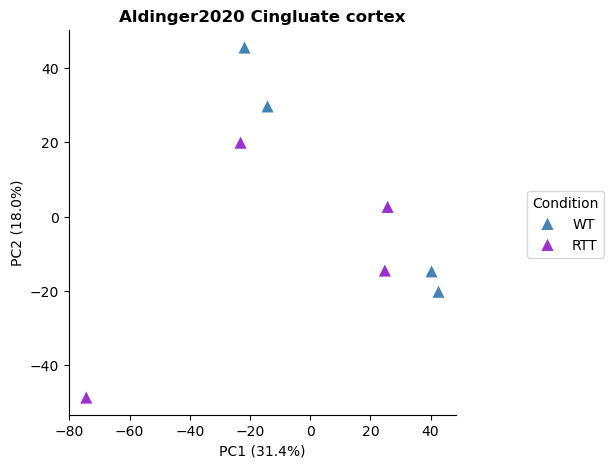

In [9]:
fig, ax = plt.subplots(figsize = (5 ,5))

palette_pca = {
    'RTT' : 'darkorchid',
    'WT' : 'steelblue'
}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : 'WT'})
sns.scatterplot(pca_df, x = 'PC1', y = 'PC2', hue = 'Condition', palette = palette_pca, s = 100, marker='^')

# Labels
ax.set_title('Aldinger2020 Cingluate cortex', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.show()